Performance Analytics Started
NAV: (46000, 3)
Performance: (40, 19)
Benchmark: (8050, 3)
Data Loaded Successfully
Daily Returns Calculated
CAGR Calculated
Sharpe Ratio Calculated
Sortino Ratio Calculated
Alpha Beta Calculated
Maximum Drawdown Calculated
Fund Scorecard Created
CSV Files Exported
Top 5 Chart Created
DAY 4 COMPLETED SUCCESSFULLY


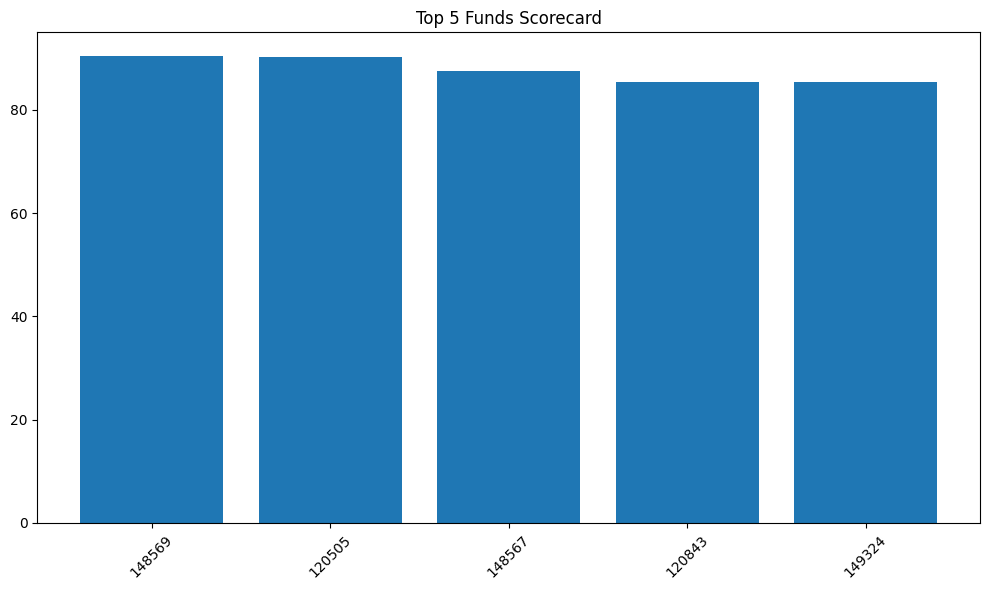

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

print("Performance Analytics Started")



nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

benchmark = pd.read_csv(
    "../data/processed/10_benchmark_indices_cleaned.csv"
)

print("NAV:", nav.shape)
print("Performance:", performance.shape)
print("Benchmark:", benchmark.shape)


nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Data Loaded Successfully")
# DAILY RETURNS

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print("Daily Returns Calculated")




cagr_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        (temp["date"].max() - temp["date"].min()).days
        / 365.25
    )

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    cagr_list.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "cagr_pct"]
)

print("CAGR Calculated")




rf = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    annual_return = temp.mean() * 252

    annual_vol = temp.std() * np.sqrt(252)

    sharpe = (annual_return - rf) / annual_vol

    sharpe_list.append([fund, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

print("Sharpe Ratio Calculated")


sortino_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]["daily_return"].dropna()

    downside = temp[temp < 0]

    annual_return = temp.mean() * 252

    downside_std = downside.std() * np.sqrt(252)

    sortino = (annual_return - rf) / downside_std

    sortino_list.append([fund, sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

print("Sortino Ratio Calculated")


benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        benchmark[["date", "benchmark_return"]],
        on="date"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope

        alpha = intercept * 252

        alpha_beta.append(
            [fund, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

print("Alpha Beta Calculated")


drawdown_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = temp["nav"].cummax()

    temp["drawdown"] = (
        temp["nav"] /
        temp["running_max"] - 1
    )

    max_dd = temp["drawdown"].min()

    drawdown_list.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

print("Maximum Drawdown Calculated")

scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)

scorecard["score"] = (
    scorecard["cagr_pct"].rank(pct=True) * 30 +
    scorecard["sharpe_ratio"].rank(pct=True) * 25 +
    scorecard["alpha"].rank(pct=True) * 20 +
    scorecard["sortino_ratio"].rank(pct=True) * 15 +
    scorecard["max_drawdown"].rank(
        ascending=False,
        pct=True
    ) * 10
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

print("Fund Scorecard Created")



scorecard.to_csv(
    "../dashboard/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../dashboard/alpha_beta.csv",
    index=False
)

print("CSV Files Exported")


# TOP 5 FUNDS CHART

top5 = scorecard.head(5)

plt.figure(figsize=(10,6))

plt.bar(
    top5["amfi_code"].astype(str),
    top5["score"]
)

plt.title("Top 5 Funds Scorecard")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../dashboard/top5_funds.png"
)

print("Top 5 Chart Created")

print("DAY 4 COMPLETED SUCCESSFULLY")